# Part 1: GPU Memory Estimation for LLM Training

This notebook estimates GPU memory requirements for training language models of various sizes.
We compute:
1. Weights-only footprint
2. Training footprint (full precision vs. 4-bit QLoRA)
3. Auxiliary memory components (gradients, optimizer state, activations)
4. Effect of `max_length` on memory consumption

**No GPU needed** — all values are formula-based estimates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Model Specifications

We pick representative models for each size category:

| Size | Model | Params | Hidden Dim | Layers | Heads | Intermediate |
|------|-------|--------|-----------|--------|-------|----------|
| 1B   | Qwen2.5-1.5B | 1.54B | 1536 | 28 | 12 | 8960 |
| 3B   | Llama-3.2-3B | 3.21B | 3072 | 28 | 24 | 8192 |
| 8B   | Llama-3.1-8B | 8.03B | 4096 | 32 | 32 | 14336 |
| 13B  | Llama-2-13B  | 13.02B | 5120 | 40 | 40 | 13824 |

In [2]:
# Model specifications
models = {
    '1B (Qwen2.5-1.5B)': {
        'params_B': 1.54,
        'hidden_dim': 1536,
        'num_layers': 28,
        'num_heads': 12,
        'intermediate_size': 8960,
        'head_dim': 128,
        'num_kv_heads': 2,  # GQA
        'vocab_size': 151936,
    },
    '3B (Llama-3.2-3B)': {
        'params_B': 3.21,
        'hidden_dim': 3072,
        'num_layers': 28,
        'num_heads': 24,
        'intermediate_size': 8192,
        'head_dim': 128,
        'num_kv_heads': 8,  # GQA
        'vocab_size': 128256,
    },
    '8B (Llama-3.1-8B)': {
        'params_B': 8.03,
        'hidden_dim': 4096,
        'num_layers': 32,
        'num_heads': 32,
        'intermediate_size': 14336,
        'head_dim': 128,
        'num_kv_heads': 8,  # GQA
        'vocab_size': 128256,
    },
    '13B (Llama-2-13B)': {
        'params_B': 13.02,
        'hidden_dim': 5120,
        'num_layers': 40,
        'num_heads': 40,
        'intermediate_size': 13824,
        'head_dim': 128,
        'num_kv_heads': 40,  # MHA (no GQA)
        'vocab_size': 32000,
    },
}

## 2. Weights-Only Footprint

**Formula:**
$$\text{Memory}_{\text{weights}} = N_{\text{params}} \times b$$

Where $b$ is bytes per parameter:
- FP32: 4 bytes
- FP16 / BF16: 2 bytes
- INT8: 1 byte
- INT4 (NF4): 0.5 bytes

In [3]:
def weights_memory_gb(params_B, bytes_per_param):
    """Calculate weight memory in GB."""
    return (params_B * 1e9 * bytes_per_param) / (1024**3)

# Build weights-only table
weights_data = []
for name, spec in models.items():
    p = spec['params_B']
    weights_data.append({
        'Model': name,
        'Params (B)': p,
        'FP32 (GB)': weights_memory_gb(p, 4),
        'FP16/BF16 (GB)': weights_memory_gb(p, 2),
        'INT8 (GB)': weights_memory_gb(p, 1),
        'INT4/NF4 (GB)': weights_memory_gb(p, 0.5),
    })

df_weights = pd.DataFrame(weights_data)
print("=== Weights-Only GPU Memory Footprint ===")
print(df_weights.to_string(index=False))

=== Weights-Only GPU Memory Footprint ===
            Model  Params (B)  FP32 (GB)  FP16/BF16 (GB)  INT8 (GB)  INT4/NF4 (GB)
1B (Qwen2.5-1.5B)        1.54       5.74            2.87       1.43           0.72
3B (Llama-3.2-3B)        3.21      11.96            5.98       2.99           1.49
8B (Llama-3.1-8B)        8.03      29.91           14.96       7.48           3.74
13B (Llama-2-13B)       13.02      48.50           24.25      12.13           6.06


## 3. Training Footprint — Full Precision vs. 4-bit (QLoRA)

### Full-Precision Training (FP16 mixed precision with AdamW)

For mixed-precision training with AdamW, per parameter we need:
- **Model weights (FP16)**: 2 bytes/param
- **Master weights (FP32 copy)**: 4 bytes/param 
- **Gradients (FP16)**: 2 bytes/param
- **Optimizer state (AdamW)**: 8 bytes/param (FP32 momentum + FP32 variance)

**Total ≈ 16 bytes/param** for mixed-precision AdamW

### QLoRA Training

- **Base model weights**: quantized to NF4 → 0.5 bytes/param
- **LoRA adapters**: typically ~0.5–2% of total params, trained in BF16
  - LoRA adapter params get: weights (2B) + grads (2B) + optimizer (8B) = 12 bytes/param
- **Quantization overhead**: ~0.5 bytes/param for quantization constants

In [4]:
def full_precision_training_gb(params_B):
    """Mixed precision (FP16 + FP32 master) with AdamW: ~16 bytes/param."""
    bytes_per_param = 16  # 2 (fp16 weights) + 4 (fp32 master) + 2 (grads) + 8 (optimizer)
    return (params_B * 1e9 * bytes_per_param) / (1024**3)

def qlora_training_gb(params_B, lora_ratio=0.01, quant_overhead=0.5):
    """
    QLoRA training memory:
    - Base model: NF4 quantized (0.5 bytes/param) + quant overhead
    - LoRA params: 12 bytes/param (BF16 weights + grads + AdamW optimizer)
    """
    base_params = params_B * 1e9
    lora_params = base_params * lora_ratio
    
    base_mem = base_params * (0.5 + quant_overhead)  # NF4 + quantization constants
    lora_mem = lora_params * 12  # BF16 weights(2) + grads(2) + optimizer(8)
    
    total = (base_mem + lora_mem) / (1024**3)
    return total, (base_mem / (1024**3)), (lora_mem / (1024**3))

# Build training footprint table
training_data = []
for name, spec in models.items():
    p = spec['params_B']
    full_prec = full_precision_training_gb(p)
    qlora_total, qlora_base, qlora_lora = qlora_training_gb(p)
    
    training_data.append({
        'Model': name,
        'Full Precision Training (GB)': full_prec,
        'QLoRA Total (GB)': qlora_total,
        'QLoRA Base Weights (GB)': qlora_base,
        'QLoRA LoRA Adapters (GB)': qlora_lora,
        'Memory Savings': f'{(1 - qlora_total/full_prec)*100:.0f}%',
    })

df_training = pd.DataFrame(training_data)
print("=== Training Memory Footprint (excluding activations) ===")
print(df_training.to_string(index=False))
print("\nNote: Full precision = FP16 mixed precision with FP32 master weights + AdamW")
print("QLoRA = NF4 quantized base + BF16 LoRA adapters (1% of params) + AdamW for LoRA only")

=== Training Memory Footprint (excluding activations) ===
            Model  Full Precision Training (GB)  QLoRA Total (GB)  QLoRA Base Weights (GB)  QLoRA LoRA Adapters (GB) Memory Savings
1B (Qwen2.5-1.5B)                         22.95              1.61                     1.43                      0.17            93%
3B (Llama-3.2-3B)                         47.83              3.35                     2.99                      0.36            93%
8B (Llama-3.1-8B)                        119.66              8.38                     7.48                      0.90            93%
13B (Llama-2-13B)                        194.01             13.58                    12.13                      1.46            93%

Note: Full precision = FP16 mixed precision with FP32 master weights + AdamW
QLoRA = NF4 quantized base + BF16 LoRA adapters (1% of params) + AdamW for LoRA only


## 4. Auxiliary Memory Components

Beyond model weights, training requires additional GPU memory for:

| Component | Full Fine-tuning | QLoRA |
|-----------|-----------------|-------|
| **Gradients** | 2 bytes/param (FP16) for all params | Only for LoRA params |
| **Optimizer (AdamW)** | 8 bytes/param (m₁ + m₂ in FP32) for all params | Only for LoRA params |
| **FP32 Master Weights** | 4 bytes/param | Only for LoRA params |
| **Activations** | Depends on batch_size × seq_len × hidden_dim × num_layers | Same |
| **KV Cache** | Not used in training (only inference) | Same |
| **CUDA Kernels + Workspace** | ~0.5-1.0 GB overhead | Same |
| **Quantization Constants** | N/A | ~0.5 bytes/param |

In [5]:
def auxiliary_breakdown_gb(params_B, lora_ratio=0.01, mode='full'):
    """Break down auxiliary memory components."""
    total_params = params_B * 1e9
    lora_params = total_params * lora_ratio
    
    if mode == 'full':
        trainable = total_params
        weights = total_params * 2  # FP16
        master_weights = total_params * 4  # FP32 copy
        quant_const = 0
    else:  # qlora
        trainable = lora_params
        weights = total_params * 0.5  # NF4
        master_weights = lora_params * 4  # FP32 copy only for LoRA
        quant_const = total_params * 0.5  # quantization constants
    
    gradients = trainable * 2       # FP16
    optimizer_m1 = trainable * 4    # FP32 first moment
    optimizer_m2 = trainable * 4    # FP32 second moment
    cuda_overhead = 0.8 * (1024**3) # ~800MB fixed overhead
    
    components = {
        'Model Weights': weights,
        'FP32 Master Weights': master_weights,
        'Gradients': gradients,
        'Optimizer (momentum)': optimizer_m1,
        'Optimizer (variance)': optimizer_m2,
        'Quantization Constants': quant_const,
        'CUDA Overhead': cuda_overhead,
    }
    
    return {k: v / (1024**3) for k, v in components.items()}

# Show detailed breakdown for each model
for name, spec in models.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    
    for mode in ['full', 'qlora']:
        breakdown = auxiliary_breakdown_gb(spec['params_B'], mode=mode)
        mode_label = 'Full Precision' if mode == 'full' else 'QLoRA (r=1% params)'
        print(f"\n  {mode_label}:")
        total = 0
        for component, gb in breakdown.items():
            if gb > 0.001:
                print(f"    {component:30s}: {gb:8.2f} GB")
                total += gb
        print(f"    {'TOTAL (excl. activations)':30s}: {total:8.2f} GB")


  1B (Qwen2.5-1.5B)

  Full Precision:
    Model Weights                 :     2.87 GB
    FP32 Master Weights           :     5.74 GB
    Gradients                     :     2.87 GB
    Optimizer (momentum)          :     5.74 GB
    Optimizer (variance)          :     5.74 GB
    CUDA Overhead                 :     0.80 GB
    TOTAL (excl. activations)     :    23.75 GB

  QLoRA (r=1% params):
    Model Weights                 :     0.72 GB
    FP32 Master Weights           :     0.06 GB
    Gradients                     :     0.03 GB
    Optimizer (momentum)          :     0.06 GB
    Optimizer (variance)          :     0.06 GB
    Quantization Constants        :     0.72 GB
    CUDA Overhead                 :     0.80 GB
    TOTAL (excl. activations)     :     2.44 GB

  3B (Llama-3.2-3B)

  Full Precision:
    Model Weights                 :     5.98 GB
    FP32 Master Weights           :    11.96 GB
    Gradients                     :     5.98 GB
    Optimizer (momentum)        

## 5. Effect of `max_length` on Memory (Activation Memory)

Activation memory during training is the dominant variable cost. For a transformer:

$$\text{Activation Memory} \approx 2 \times B \times S \times H \times L \times b_{\text{act}}$$

Where:
- $B$ = batch size
- $S$ = sequence length (`max_length`)
- $H$ = hidden dimension
- $L$ = number of layers
- $b_{\text{act}}$ = bytes per activation (2 for FP16)
- Factor of 2 accounts for forward + backward pass

More precisely, per transformer layer, activations include:
- Attention: $4 \times B \times S \times H$ (Q, K, V projections + output)
- Attention scores: $B \times n_{\text{heads}} \times S^2$ (quadratic in sequence length!)
- FFN: $2 \times B \times S \times d_{\text{ff}}$ (two linear layers)
- Layer norms, residuals, etc.

With gradient checkpointing, activation memory drops by ~$\sqrt{L}$ factor.

In [6]:
def activation_memory_gb(hidden_dim, num_layers, num_heads, intermediate_size, 
                          seq_len, batch_size=1, bytes_per_act=2, 
                          gradient_checkpointing=True):
    """
    Estimate activation memory for a transformer model during training.
    
    Per layer activations (in elements):
    - Self-attention: input(B*S*H) + QKV(3*B*S*H) + attn_scores(B*n_h*S*S) + attn_output(B*S*H)
    - FFN: input(B*S*H) + hidden(B*S*d_ff) + output(B*S*H)
    - Layer norms, residuals: ~2 * B*S*H
    """
    B, S, H = batch_size, seq_len, hidden_dim
    n_h = num_heads
    d_ff = intermediate_size
    
    # Per-layer activation elements
    attn_activations = 4 * B * S * H + B * n_h * S * S  # QKV + scores
    ffn_activations = B * S * H + B * S * d_ff + B * S * H  # input + hidden + output
    norm_residual = 2 * B * S * H
    
    per_layer = attn_activations + ffn_activations + norm_residual
    
    if gradient_checkpointing:
        # With checkpointing, we only store activations for sqrt(L) layers
        effective_layers = int(np.sqrt(num_layers)) + 1
        # But we also need to recompute within each segment
        segment_size = int(np.sqrt(num_layers))
        total_elements = per_layer * (effective_layers + segment_size)
    else:
        total_elements = per_layer * num_layers
    
    # Factor of ~2 for forward + backward pass stored simultaneously
    total_bytes = total_elements * bytes_per_act * 2
    return total_bytes / (1024**3)

# Sequence lengths to test
seq_lengths = [256, 512, 1024, 2048]
batch_size = 1

print(f"=== Activation Memory vs. max_length (batch_size={batch_size}) ===")
print(f"{'Model':<25s}", end='')
for sl in seq_lengths:
    print(f"{'S='+str(sl):>12s}", end='')
print()
print('-' * 73)

activation_data = []
for name, spec in models.items():
    row = {'Model': name}
    print(f"{name:<25s}", end='')
    for sl in seq_lengths:
        mem = activation_memory_gb(
            hidden_dim=spec['hidden_dim'],
            num_layers=spec['num_layers'],
            num_heads=spec['num_heads'],
            intermediate_size=spec['intermediate_size'],
            seq_len=sl,
            batch_size=batch_size,
            gradient_checkpointing=True,
        )
        row[f'S={sl}'] = mem
        print(f"{mem:>10.2f}GB", end='')
    print()
    activation_data.append(row)

print("\n(With gradient checkpointing enabled, batch_size=1)")

=== Activation Memory vs. max_length (batch_size=1) ===
Model                           S=256       S=512      S=1024      S=2048
-------------------------------------------------------------------------
1B (Qwen2.5-1.5B)              0.26GB      0.57GB      1.41GB      3.85GB
3B (Llama-3.2-3B)              0.41GB      0.95GB      2.41GB      6.88GB
8B (Llama-3.1-8B)              0.58GB      1.33GB      3.35GB      9.45GB
13B (Llama-2-13B)              0.81GB      1.87GB      4.75GB     13.56GB

(With gradient checkpointing enabled, batch_size=1)


In [7]:
# Same table WITHOUT gradient checkpointing for comparison
print(f"\n=== Activation Memory vs. max_length — NO gradient checkpointing ===")
print(f"{'Model':<25s}", end='')
for sl in seq_lengths:
    print(f"{'S='+str(sl):>12s}", end='')
print()
print('-' * 73)

for name, spec in models.items():
    print(f"{name:<25s}", end='')
    for sl in seq_lengths:
        mem = activation_memory_gb(
            hidden_dim=spec['hidden_dim'],
            num_layers=spec['num_layers'],
            num_heads=spec['num_heads'],
            intermediate_size=spec['intermediate_size'],
            seq_len=sl,
            batch_size=batch_size,
            gradient_checkpointing=False,
        )
        print(f"{mem:>10.2f}GB", end='')
    print()

print("\n(NO gradient checkpointing, batch_size=1)")


=== Activation Memory vs. max_length — NO gradient checkpointing ===
Model                           S=256       S=512      S=1024      S=2048
-------------------------------------------------------------------------
1B (Qwen2.5-1.5B)              0.65GB      1.46GB      3.58GB      9.79GB
3B (Llama-3.2-3B)              1.04GB      2.41GB      6.12GB     17.50GB
8B (Llama-3.1-8B)              1.69GB      3.88GB      9.75GB     27.50GB
13B (Llama-2-13B)              2.48GB      5.74GB     14.61GB     41.72GB

(NO gradient checkpointing, batch_size=1)


## 6. Total Memory Estimation (Weights + Optimizer + Activations)

Now let's combine everything: total estimated GPU memory for training.

In [8]:
# Total memory estimation: QLoRA with gradient checkpointing, seq_len=512
print("=" * 80)
print("TOTAL GPU MEMORY ESTIMATE — QLoRA + Gradient Checkpointing")
print(f"batch_size=1, LoRA ratio=1% of params")
print("=" * 80)

summary_data = []
for name, spec in models.items():
    print(f"\n--- {name} ---")
    for sl in seq_lengths:
        # QLoRA base memory (weights + optimizer for LoRA only)
        qlora_total, _, _ = qlora_training_gb(spec['params_B'])
        
        # Activations
        act_mem = activation_memory_gb(
            hidden_dim=spec['hidden_dim'],
            num_layers=spec['num_layers'],
            num_heads=spec['num_heads'],
            intermediate_size=spec['intermediate_size'],
            seq_len=sl,
            batch_size=1,
            gradient_checkpointing=True,
        )
        
        cuda_overhead = 0.8  # GB
        total = qlora_total + act_mem + cuda_overhead
        fits_2080 = '✓' if total <= 11.0 else '✗'
        
        summary_data.append({
            'Model': name,
            'Seq Len': sl,
            'QLoRA Base (GB)': qlora_total,
            'Activations (GB)': act_mem,
            'CUDA Overhead (GB)': cuda_overhead,
            'Total (GB)': total,
            'Fits RTX 2080 (11GB)': fits_2080
        })
        
        print(f"  seq_len={sl:5d}: QLoRA={qlora_total:.1f}GB + Act={act_mem:.2f}GB + CUDA=0.8GB = {total:.1f}GB {fits_2080}")

df_summary = pd.DataFrame(summary_data)
print("\n\nNote: RTX 2080 has 11GB VRAM. Models marked ✓ are expected to fit.")

TOTAL GPU MEMORY ESTIMATE — QLoRA + Gradient Checkpointing
batch_size=1, LoRA ratio=1% of params

--- 1B (Qwen2.5-1.5B) ---
  seq_len=  256: QLoRA=1.6GB + Act=0.26GB + CUDA=0.8GB = 2.7GB ✓
  seq_len=  512: QLoRA=1.6GB + Act=0.57GB + CUDA=0.8GB = 3.0GB ✓
  seq_len= 1024: QLoRA=1.6GB + Act=1.41GB + CUDA=0.8GB = 3.8GB ✓
  seq_len= 2048: QLoRA=1.6GB + Act=3.85GB + CUDA=0.8GB = 6.3GB ✓

--- 3B (Llama-3.2-3B) ---
  seq_len=  256: QLoRA=3.3GB + Act=0.41GB + CUDA=0.8GB = 4.6GB ✓
  seq_len=  512: QLoRA=3.3GB + Act=0.95GB + CUDA=0.8GB = 5.1GB ✓
  seq_len= 1024: QLoRA=3.3GB + Act=2.41GB + CUDA=0.8GB = 6.6GB ✓
  seq_len= 2048: QLoRA=3.3GB + Act=6.88GB + CUDA=0.8GB = 11.0GB ✗

--- 8B (Llama-3.1-8B) ---
  seq_len=  256: QLoRA=8.4GB + Act=0.58GB + CUDA=0.8GB = 9.8GB ✓
  seq_len=  512: QLoRA=8.4GB + Act=1.33GB + CUDA=0.8GB = 10.5GB ✓
  seq_len= 1024: QLoRA=8.4GB + Act=3.35GB + CUDA=0.8GB = 12.5GB ✗
  seq_len= 2048: QLoRA=8.4GB + Act=9.45GB + CUDA=0.8GB = 18.6GB ✗

--- 13B (Llama-2-13B) ---
  seq_len= 

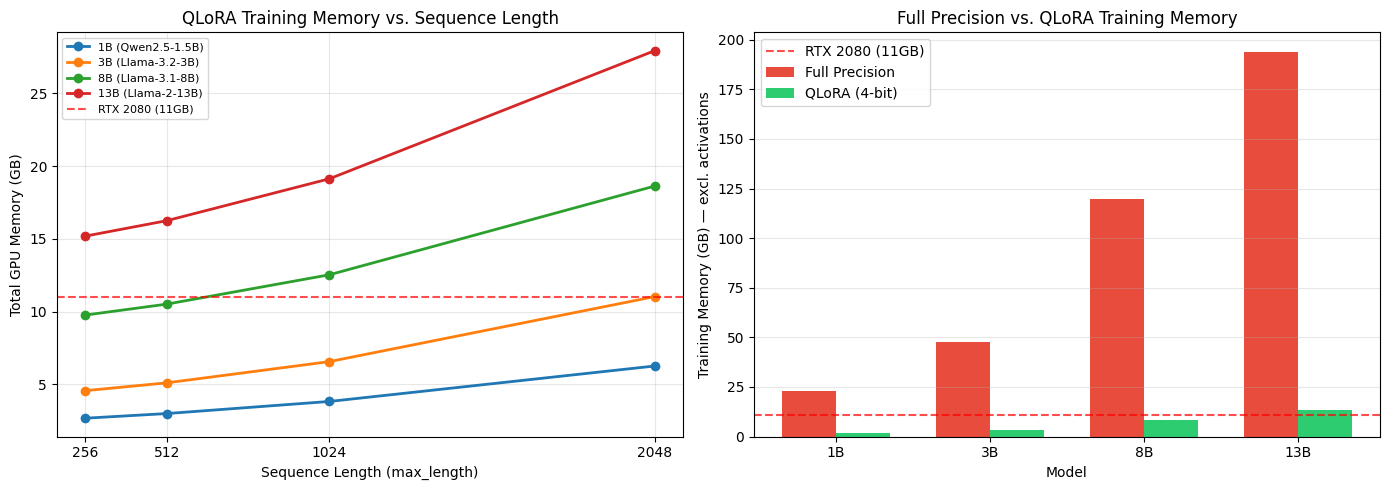

Saved: memory_estimation_plots.png


In [9]:
# Visualization: Memory scaling with sequence length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total memory (QLoRA) vs sequence length
ax1 = axes[0]
for name in models:
    subset = df_summary[df_summary['Model'] == name]
    ax1.plot(subset['Seq Len'], subset['Total (GB)'], 'o-', label=name, linewidth=2)

ax1.axhline(y=11, color='red', linestyle='--', label='RTX 2080 (11GB)', alpha=0.7)
ax1.set_xlabel('Sequence Length (max_length)')
ax1.set_ylabel('Total GPU Memory (GB)')
ax1.set_title('QLoRA Training Memory vs. Sequence Length')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(seq_lengths)

# Plot 2: Comparison of Full Precision vs QLoRA
ax2 = axes[1]
model_names = list(models.keys())
full_prec_mem = [full_precision_training_gb(models[m]['params_B']) for m in model_names]
qlora_mem = [qlora_training_gb(models[m]['params_B'])[0] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
ax2.bar(x - width/2, full_prec_mem, width, label='Full Precision', color='#e74c3c')
ax2.bar(x + width/2, qlora_mem, width, label='QLoRA (4-bit)', color='#2ecc71')
ax2.axhline(y=11, color='red', linestyle='--', label='RTX 2080 (11GB)', alpha=0.7)

ax2.set_xlabel('Model')
ax2.set_ylabel('Training Memory (GB) — excl. activations')
ax2.set_title('Full Precision vs. QLoRA Training Memory')
ax2.set_xticks(x)
ax2.set_xticklabels(['1B', '3B', '8B', '13B'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('memory_estimation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: memory_estimation_plots.png")

## 7. Summary & Model Choice

### Key Formulas Used

| Component | Formula | Notes |
|-----------|---------|-------|
| Weights (FP16) | $N \times 2$ bytes | |
| Weights (NF4) | $N \times 0.5$ bytes | + quantization constants |
| Gradients | $N_{\text{trainable}} \times 2$ bytes | FP16 |
| AdamW Optimizer | $N_{\text{trainable}} \times 8$ bytes | $m_1$ (FP32) + $m_2$ (FP32) |
| Master Weights | $N_{\text{trainable}} \times 4$ bytes | FP32 copy |
| Activations (per layer) | $\sim B \times S \times (7H + n_h \times S + 2d_{ff})$ elements | × 2 bytes × 2 (fwd+bwd) |

### Conclusions

- **1B models** fit comfortably on RTX 2080 even with full-precision LoRA training
- **3B models** fit with QLoRA and moderate sequence lengths
- **8B models** require QLoRA + gradient checkpointing + short sequences
- **13B models** are too large for RTX 2080 even with QLoRA
- QLoRA provides **~90-95%** memory savings vs full precision

### Chosen Model

Based on the analysis, we choose **Qwen2.5-1.5B** (or **Llama-3.2-3B** with QLoRA) as it:
1. Fits on RTX 2080 with room for activations
2. Is large enough to demonstrate meaningful LoRA adaptation
3. Has a good tokenizer for English text
4. Will be manageable for Part 2 (SFT fine-tuning)

In [10]:
# Final combined table for the report
print("\n" + "="*90)
print("COMBINED REPORT TABLE")
print("="*90)

report_data = []
for name, spec in models.items():
    p = spec['params_B']
    qlora_total, _, _ = qlora_training_gb(p)
    act_512 = activation_memory_gb(
        spec['hidden_dim'], spec['num_layers'], spec['num_heads'],
        spec['intermediate_size'], seq_len=512, gradient_checkpointing=True
    )
    report_data.append({
        'Model': name,
        'Params': f'{p}B',
        'Weights FP16': f'{weights_memory_gb(p, 2):.1f} GB',
        'Weights NF4': f'{weights_memory_gb(p, 0.5):.1f} GB',
        'Train Full Prec': f'{full_precision_training_gb(p):.1f} GB',
        'Train QLoRA': f'{qlora_total:.1f} GB',
        'Act. (S=512)': f'{act_512:.2f} GB',
        'Total QLoRA (S=512)': f'{qlora_total + act_512 + 0.8:.1f} GB',
        'Fits 11GB?': '✓' if (qlora_total + act_512 + 0.8) <= 11 else '✗',
    })

df_report = pd.DataFrame(report_data)
print(df_report.to_string(index=False))


COMBINED REPORT TABLE
            Model Params Weights FP16 Weights NF4 Train Full Prec Train QLoRA Act. (S=512) Total QLoRA (S=512) Fits 11GB?
1B (Qwen2.5-1.5B)  1.54B       2.9 GB      0.7 GB         22.9 GB      1.6 GB      0.57 GB              3.0 GB          ✓
3B (Llama-3.2-3B)  3.21B       6.0 GB      1.5 GB         47.8 GB      3.3 GB      0.95 GB              5.1 GB          ✓
8B (Llama-3.1-8B)  8.03B      15.0 GB      3.7 GB        119.7 GB      8.4 GB      1.33 GB             10.5 GB          ✓
13B (Llama-2-13B) 13.02B      24.3 GB      6.1 GB        194.0 GB     13.6 GB      1.87 GB             16.2 GB          ✗
